In [173]:
### Homework 4 Code - Karann Singam - 801285554 ###

from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC, SVR
from sklearn import metrics
import matplotlib.pyplot as plt

# Mounting Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Baseline Accuracy = 0.9649122807017544 
Baseline Precision = 0.9787234042553191 
Baseline Recall = 0.9387755102040817

Tuned Accuracy = 0.9736842105263158 
Tuned Precision = 1.0 
Tuned Recall = 0.9387755102040817 



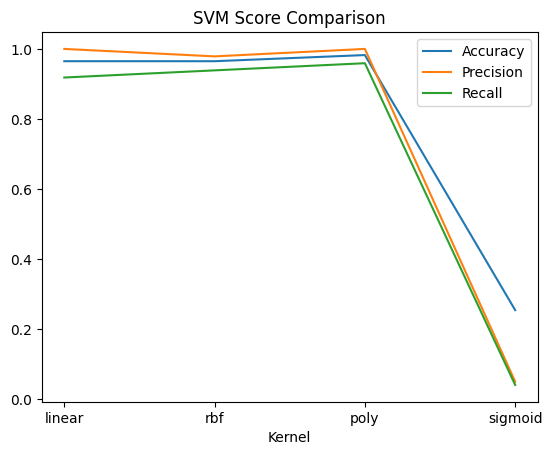

In [174]:
### Problem 1 ###

# Reading CSV file
df = pd.read_csv('/content/drive/MyDrive/ECGR_4105/Datasets/Cancer.csv')

# Initializing variables
Y = df.iloc[:, 1]
Y = Y.map({"B": 0, "M": 1})
X = df.iloc[:, 2:32]

# Splitting 80/20 for training/test
XT, XV, YT, YV = train_test_split(X, Y, train_size = 0.8, test_size = 0.2, random_state = 100)

# Standardization
scaler = MinMaxScaler()
XT = scaler.fit_transform(XT)
XV = scaler.transform(XV)

# Baseline SVM classification and finding metrics
classifier = SVC(kernel = "rbf")
classifier.fit(XT, YT)
predictions = classifier.predict(XV)
accuracy = metrics.accuracy_score(YV, predictions)
precision = metrics.precision_score(YV, predictions)
recall = metrics.recall_score(YV, predictions)
print("Baseline Accuracy =", accuracy, "\nBaseline Precision =", precision, "\nBaseline Recall =", recall)

# Tuned SVM classification using altered C, and gamma and finding metrics
classifier = SVC(kernel = "poly", C = 0.7, gamma = 0.7)
classifier.fit(XT, YT)
predictions = classifier.predict(XV)
accuracy = metrics.accuracy_score(YV, predictions)
precision = metrics.precision_score(YV, predictions)
recall = metrics.recall_score(YV, predictions)
print("\nTuned Accuracy =", accuracy, "\nTuned Precision =", precision, "\nTuned Recall =", recall, "\n")

# Trying out different kernels
kernels = ["linear", "rbf", "poly", "sigmoid"]
accuracies = []
precisions = []
recalls = []
for kernel in kernels:
  classifier = SVC(kernel = kernel)
  classifier.fit(XT, YT)
  predictions = classifier.predict(XV)
  accuracies.append(metrics.accuracy_score(YV, predictions))
  precisions.append(metrics.precision_score(YV, predictions))
  recalls.append(metrics.recall_score(YV, predictions))

# Plotting results
plt.figure()
plt.plot(kernels, accuracies, label = "Accuracy")
plt.plot(kernels, precisions, label = "Precision")
plt.plot(kernels, recalls, label = "Recall")
plt.title("SVM Score Comparison")
plt.xlabel("Kernel")
plt.legend()
plt.show()

/tmp/ipykernel_485/1591433968.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"no": 0, "yes": 1})


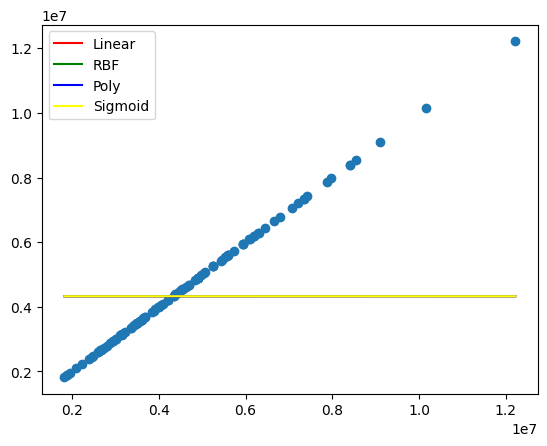

In [175]:
### Problem 2 ###

# Changing dataset and enumerating values
df = pd.read_csv('/content/drive/MyDrive/ECGR_4105/Datasets/Housing.csv')
df = df.replace({"no": 0, "yes": 1})

# Initializing variables
Y = df.iloc[:, 0].values
X = df.iloc[:, 1:12].values

# Splitting 80/20 for training/test
XT, XV, YT, YV = train_test_split(X, Y, train_size = 0.8, test_size = 0.2, random_state = 100)

# Standardization
scaler = MinMaxScaler().fit(XT)
XT = scaler.transform(XT)
XV = scaler.transform(XV)

# SVR (regression)
regressor = SVR(kernel = "linear")
prediction_linear = regressor.fit(XT, YT).predict(XV)
regressor = SVR(kernel = "rbf")
prediction_rbf = regressor.fit(XT, YT).predict(XV)
regressor = SVR(kernel = "poly")
prediction_poly = regressor.fit(XT, YT).predict(XV)
regressor = SVR(kernel = "sigmoid")
prediction_sigmoid = regressor.fit(XT, YT).predict(XV)

# Plotting
plt.figure()
plt.scatter(YV, YV)
plt.plot([YV.min(), YV.max()], [prediction_linear.min(), prediction_linear.max()], color = "red", label = "Linear")
plt.plot([YV.min(), YV.max()], [prediction_rbf.min(), prediction_rbf.max()], color = "green", label = "RBF")
plt.plot([YV.min(), YV.max()], [prediction_poly.min(), prediction_poly.max()], color = "blue", label = "Poly")
plt.plot([YV.min(), YV.max()], [prediction_sigmoid.min(), prediction_sigmoid.max()], color = "yellow", label = "Sigmoid")
plt.legend()
plt.show()